In [1]:
import zipfile
import os

zip_file_path = '/content/Data.zip'
output_directory = '/content/extracted_data'

# Create the output directory if it doesn't exist
os.makedirs(output_directory, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_directory)

print(f"File '{zip_file_path}' unzipped to '{output_directory}'")

# List the contents of the extracted directory
print("\nContents of extracted_data:")
print(os.listdir(output_directory))

File '/content/Data.zip' unzipped to '/content/extracted_data'

Contents of extracted_data:
['train_identity.csv', 'train_transaction.csv', 'sample_submission.csv', 'test_identity.csv', 'test_transaction.csv']


In [2]:
import pandas as pd
import os
from sklearn.metrics import roc_auc_score
import numpy as np
import gc
import sys

# Clear previous large dataframes if they exist
for var_name in ['X_train', 'X_test', 'y_train', 'oof', 'preds']:
    if var_name in globals():
        del globals()[var_name]
gc.collect()

paths = {
    "train_transaction": "/content/extracted_data/train_transaction.csv",
    "train_identity": "/content/extracted_data/train_identity.csv",
    "test_transaction": "/content/extracted_data/test_transaction.csv",
    "test_identity": "/content/extracted_data/test_identity.csv"
}
# Check file sizes and row counts
for name, path in paths.items():
    rows = sum(1 for line in open(path)) - 1
    size_gb = os.path.getsize(path) / (1024**3)
    print(f"{name}: {rows} rows | {size_gb:.2f} GB")

# 1. PATH DEFINITIONS
path_train_transaction = "/content/extracted_data/train_transaction.csv"
path_train_id = "/content/extracted_data/train_identity.csv"
path_test_transaction = "/content/extracted_data/test_transaction.csv"
path_test_id = "/content/extracted_data/test_identity.csv"

# 2. OPTIMIZED LOADER
def load_and_merge():
    print("Loading Transactions...")
    train_trans = pd.read_csv(path_train_transaction, index_col='TransactionID', low_memory=False)
    test_trans = pd.read_csv(path_test_transaction, index_col='TransactionID', low_memory=False)

    print("Loading Identity...")
    train_id = pd.read_csv(path_train_id, index_col='TransactionID', low_memory=False)
    test_id = pd.read_csv(path_test_id, index_col='TransactionID', low_memory=False)

    # This ensures both match the script's 'id_01' style
    train_id.columns = [c.replace('-', '_') for c in train_id.columns]
    test_id.columns = [c.replace('-', '_') for c in test_id.columns]

    print("Merging Tables...")
    train = train_trans.merge(train_id, how='left', left_index=True, right_index=True)
    test = test_trans.merge(test_id, how='left', left_index=True, right_index=True)

    # Free up RAM immediately
    del train_trans, train_id, test_trans, test_id
    gc.collect()

    return train, test

X_train, X_test = load_and_merge()

y_train = X_train['isFraud']
del X_train['isFraud']

# --- START NEW FEATURE ENGINEERING BLOCK ---

# Email and Domain Cleaning
print("Cleaning Email Domains...")
emails = {
    'gmail': 'Google', 'att.net': 'Other', 'twc.com': 'Other', 'verizon.net': 'Other',
    'hotmail.com': 'Microsoft', 'aol.com': 'Other', 'live.com': 'Microsoft',
    'outlook.com': 'Microsoft', 'yahoo.com': 'Yahoo', 'msn.com': 'Microsoft',
    'comcast.net': 'Other', 'ymail.com': 'Yahoo', 'icloud.com': 'Apple',
    'sbcglobal.net': 'Other', 'frontier.com': 'Other', 'roadrunner.com': 'Other',
    'netzero.net': 'Other', 'web.de': 'Other', 'cfl.rr.com': 'Other', 'gmx.de': 'Other',
    'protonmail.com': 'Other', 'yahoo.co.uk': 'Yahoo', 'mail.com': 'Other',
    'outlook.es': 'Microsoft', 'outlook.fr': 'Microsoft', 'charter.net': 'Other',
    'outlook.jp': 'Microsoft', 'outlook.sa': 'Microsoft', 'outlook.com.br': 'Microsoft',
    'outlook.com': 'Microsoft', 'google.com': 'Google'
}

for col in ['P_emaildomain', 'R_emaildomain']:
    # Map existing domains to company groups, fill others with 'Unknown'
    X_train[col] = X_train[col].map(emails).fillna('Unknown')
    X_test[col] = X_test[col].map(emails).fillna('Unknown')

# 2. Add "Cents" feature
print("Creating cents feature...")
X_train['cents'] = (X_train['TransactionAmt'] - np.floor(X_train['TransactionAmt'])).astype('float32')
X_test['cents'] = (X_test['TransactionAmt'] - np.floor(X_test['TransactionAmt'])).astype('float32')
print("Cents feature created.")


# 1. TIME TRANSFORMATION (D-Features)

# This converts "Days since some event" to a fixed point in time
for i in range(1, 16):
    if i in [1, 2, 3, 5, 9]: continue
    X_train["D" + str(i)] = X_train["D" + str(i)] - X_train["TransactionDT"] / np.float32(60 * 60 * 24)
    X_test["D" + str(i)] = X_test["D" + str(i)] - X_test["TransactionDT"] / np.float32(60 * 60 * 24)

# 2. CREATE THE UID

# Combining card info + address + a time-offset to identify a unique person
X_train['day'] = X_train.TransactionDT / (24 * 60 * 60)
X_test['day'] = X_test.TransactionDT / (24 * 60 * 60)

# We use card1 and addr1 to start building the UID
X_train['uid'] = X_train.card1.astype(str)+'_'+X_train.addr1.astype(str)+'_'+np.floor(X_train.day-X_train.D1).astype(str)
X_test['uid'] = X_test.card1.astype(str)+'_'+X_test.addr1.astype(str)+'_'+np.floor(X_test.day-X_test.D1).astype(str)

# 3. SELECTING THE COLUMNS

# The 0.95 script removes the raw TransactionDT and specific D/ID columns that failed their "Consistency Test"
cols_to_drop = ['TransactionDT', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14', 'day', 'uid']

print("Feature Engineering logic applied. Ready for Aggregations?")

# Function to perform mean and std aggregations
def encode_AG(main_columns, uids, aggregations=["mean"], df_train=X_train, df_test=X_test):
    for main_column in main_columns:
        for col in uids:
            for agg_type in aggregations:
                new_column = main_column + "_" + col + "_" + agg_type
                # Combine train and test for a global view of the user's behavior
                temp_df = pd.concat([df_train[[col, main_column]], df_test[[col, main_column]]], axis=0, copy=False)

                # Calculate the statistic per UID
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                    columns={agg_type: new_column})

                # Map it back to the original data
                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_column].to_dict()

                df_train[new_column] = df_train[col].map(temp_df).astype("float32")
                df_test[new_column] = df_test[col].map(temp_df).astype("float32")

                # Fill missing values with -1
                df_train[new_column] = df_train[new_column].fillna(-1)
                df_test[new_column] = df_test[new_column].fillna(-1)
                print(f"Created: {new_column}")

# Define Frequency Encoding function
def encode_FE(df1, df2, cols):
    for col in cols:
        vc = pd.concat([df1[col], df2[col]]).value_counts(dropna=True, normalize=True)
        df1[col + "_FE"] = df1[col].map(vc).astype("float32")
        df2[col + "_FE"] = df2[col].map(vc).astype("float32")
        print(f"{col}_FE created")


print("Starting Group Aggregations (original UID)...")
encode_AG(['TransactionAmt', 'D4', 'D10', 'D15'], ['uid'], ['mean', 'std', 'max', 'min'])
encode_AG(['C' + str(x) for x in range(1, 15) if x != 3], ['uid'], ['mean'])


# 1. Transaction Velocity - Amt_div_mean
print("Calculating Transaction Velocity (Amt_div_mean)...")
X_train['Amt_div_mean'] = X_train['TransactionAmt'] / X_train['TransactionAmt_uid_mean']
X_test['Amt_div_mean'] = X_test['TransactionAmt'] / X_test['TransactionAmt_uid_mean']

# 2. Time-Based Client Consistency (Amt_diff)
print("Calculating Time-Based Client Consistency (Amt_diff)...")
X_train['Amt_diff'] = X_train.groupby('uid')['TransactionAmt'].diff().fillna(0)
X_test['Amt_diff'] = X_test.groupby('uid')['TransactionAmt'].diff().fillna(0)

# 5. Add “outsider” feature
print("Creating outsider15 feature...")
X_train['outsider15'] = (np.abs(X_train.D1 - X_train.D15) > 3).astype('int8')
X_test['outsider15'] = (np.abs(X_test.D1 - X_test.D15) > 3).astype('int8')
print("outsider15 created.")

# 3. Add UID-based frequency
print("Starting Frequency Encoding (uid)...")
encode_FE(X_train, X_test, ['uid'])

# 3. More "UID" Aggregations (UID2: Card + Addr + Email)
print("Creating UID2 and performing aggregations...")
X_train['uid2'] = X_train.card1.astype(str)+'_'+X_train.addr1.astype(str)+'_'+X_train.P_emaildomain.astype(str)
X_test['uid2'] = X_test.card1.astype(str)+'_'+X_test.addr1.astype(str)+'_'+X_test.P_emaildomain.astype(str)
encode_AG(['TransactionAmt', 'D15'], ['uid2'], ['mean', 'std'])

# 4. New UID column added, make sure to add it to cols_to_drop
print("Updating cols_to_drop with uid2...")
if 'uid2' not in cols_to_drop:
    cols_to_drop.append('uid2')

# 1. Add Frequency Encoding for other columns
print("Starting Frequency Encoding (card1, card2, card3, addr1, P_emaildomain)...")
encode_FE(X_train, X_test, [
    'card1', 'card2', 'card3', 'addr1', 'P_emaildomain'
])


# Standardize column names and clean up
print(f"Final feature count: {len(X_train.columns)}")


cols = list(X_train.columns)

# Remove the raw keys and temporary columns
for c in ['TransactionDT', 'day', 'uid', 'DT_M']:
    if c in cols: cols.remove(c)

# Remove "Time Inconsistent" columns
failed_cols = ['C3', 'M5', 'id_08', 'id_33', 'card4', 'id_07', 'id_14', 'id_21', 'id_30', 'id_32', 'id_34']
for c in failed_cols:
    if c in cols: cols.remove(c)


from sklearn.preprocessing import LabelEncoder

# 1. IDENTIFY STRING COLUMNS

# These are the columns the error message complained about
obj_cols = X_train[cols].select_dtypes(include=['object']).columns

print(f"Fixing {len(obj_cols)} string columns for XGBoost...")

# 2. APPLY LABEL ENCODING
for col in obj_cols:
    le = LabelEncoder()
    # Combine train and test to ensure the same numbers represent the same strings
    full_values = pd.concat([X_train[col], X_test[col]]).astype(str)
    le.fit(full_values)

    X_train[col] = le.transform(X_train[col].astype(str)).astype(np.int32)
    X_test[col] = le.transform(X_test[col].astype(str)).astype(np.int32)

print("All string columns converted to integers.")


# 2. Setup XGBoost for GPU
import xgboost as xgb

clf = xgb.XGBClassifier(
    n_estimators=5000,
    max_depth=10,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.4,
    missing=-1,
    eval_metric='auc',

    tree_method='hist',
    device='cuda',

    max_bin=256,

    early_stopping_rounds=200
)

print(f"Ready to train on {len(cols)} features using GPU.")

from sklearn.model_selection import GroupKFold
import datetime

# 1. Setup Time-Based Groups (Month-wise)
START_DATE = datetime.datetime.strptime('2017-11-30', '%Y-%m-%d')
X_train['DT_M'] = X_train['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds=x)))
X_train['DT_M'] = (X_train['DT_M'].dt.year - 2017) * 12 + X_train['DT_M'].dt.month

# 2. Initialize Output Arrays
oof = np.zeros(len(X_train))
preds = np.zeros(len(X_test))

# 3. Start 6-Fold Cross Validation
skf = GroupKFold(n_splits=6)
for i, (idxT, idxV) in enumerate(skf.split(X_train, y_train, groups=X_train['DT_M'])):
    month = X_train.iloc[idxV]['DT_M'].iloc[0]
    print(f'Fold {i} | Training on months... | Validating on Month {month}')

    # Inside your GroupKFold loop:
    h = clf.fit(
        X_train[cols].iloc[idxT],
        y_train.iloc[idxT],
        eval_set=[(X_train[cols].iloc[idxV], y_train.iloc[idxV])],
        verbose=100
    )

    oof[idxV] += clf.predict_proba(X_train[cols].iloc[idxV])[:, 1]
    preds += clf.predict_proba(X_test[cols])[:, 1] / skf.n_splits

    del h
    gc.collect()


print('#' * 20)
sample_submission = pd.read_csv('/content/extracted_data/sample_submission.csv', low_memory=False)
sample_submission.isFraud = preds
sample_submission.to_csv('sub_final_ahpcc.csv', index=False)
print("Submission file saved!")

score = roc_auc_score(y_train, oof)
print(f"Your final OOF CV Score is: {score}")


train_transaction: 590540 rows | 0.64 GB
train_identity: 144233 rows | 0.02 GB
test_transaction: 506691 rows | 0.57 GB
test_identity: 141907 rows | 0.02 GB
Loading Transactions...
Loading Identity...
Merging Tables...
Cleaning Email Domains...
Creating cents feature...
Cents feature created.
Feature Engineering logic applied. Ready for Aggregations?
Starting Group Aggregations (original UID)...
Created: TransactionAmt_uid_mean
Created: TransactionAmt_uid_std
Created: TransactionAmt_uid_max
Created: TransactionAmt_uid_min
Created: D4_uid_mean
Created: D4_uid_std
Created: D4_uid_max
Created: D4_uid_min
Created: D10_uid_mean
Created: D10_uid_std
Created: D10_uid_max
Created: D10_uid_min
Created: D15_uid_mean
Created: D15_uid_std
Created: D15_uid_max
Created: D15_uid_min
Created: C1_uid_mean
Created: C2_uid_mean
Created: C4_uid_mean
Created: C5_uid_mean
Created: C6_uid_mean
Created: C7_uid_mean
Created: C8_uid_mean
Created: C9_uid_mean
Created: C10_uid_mean
Created: C11_uid_mean
Created: C

/tmp/ipykernel_6679/1468353740.py:257: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['DT_M'] = X_train['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds=x)))


Fold 0 | Training on months... | Validating on Month 12
[0]	validation_0-auc:0.81562
[100]	validation_0-auc:0.89551
[200]	validation_0-auc:0.90770
[300]	validation_0-auc:0.91440
[400]	validation_0-auc:0.91628
[500]	validation_0-auc:0.91707
[600]	validation_0-auc:0.91713
[700]	validation_0-auc:0.91709
[800]	validation_0-auc:0.91672
[833]	validation_0-auc:0.91633


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [06:23:30] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold 1 | Training on months... | Validating on Month 15
[0]	validation_0-auc:0.82807
[100]	validation_0-auc:0.92334
[200]	validation_0-auc:0.93819
[300]	validation_0-auc:0.94494
[400]	validation_0-auc:0.94888
[500]	validation_0-auc:0.95103
[600]	validation_0-auc:0.95229
[700]	validation_0-auc:0.95309
[800]	validation_0-auc:0.95354
[900]	validation_0-auc:0.95381
[1000]	validation_0-auc:0.95383
[1100]	validation_0-auc:0.95394
[1200]	validation_0-auc:0.95380
[1259]	validation_0-auc:0.95382
Fold 2 | Training on months... | Validating on Month 13
[0]	validation_0-auc:0.82940
[100]	validation_0-auc:0.91948
[200]	validation_0-auc:0.93608
[300]	validation_0-auc:0.94278
[400]	validation_0-auc:0.94692
[500]	validation_0-auc:0.94928
[600]	validation_0-auc:0.95104
[700]	validation_0-auc:0.95148
[800]	validation_0-auc:0.95200
[900]	validation_0-auc:0.95214
[1000]	validation_0-auc:0.95234
[1100]	validation_0-auc:0.95259
[1200]	validation_0-auc:0.95241
[1300]	validation_0-auc:0.95214
[1309]	validatio

### 📊 Research Visualization Block
This section generates the standard figures required for a research-level report, including class distribution, validation strategy, and model interpretability.

/tmp/ipykernel_17422/332767216.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_train, palette='viridis')


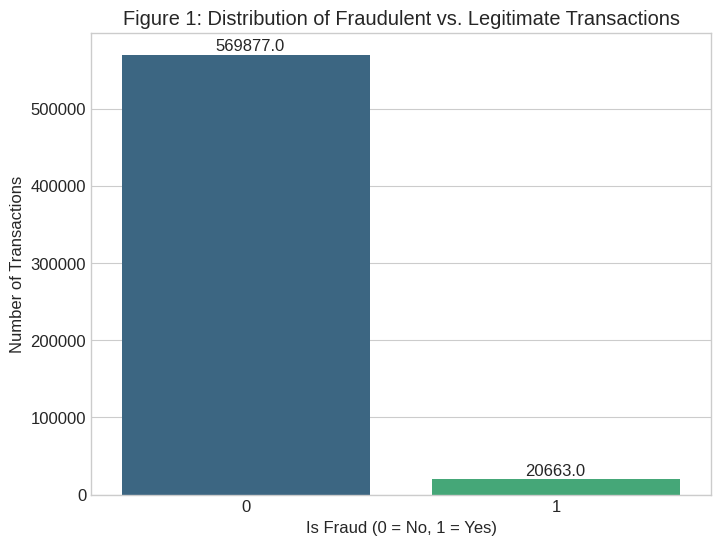

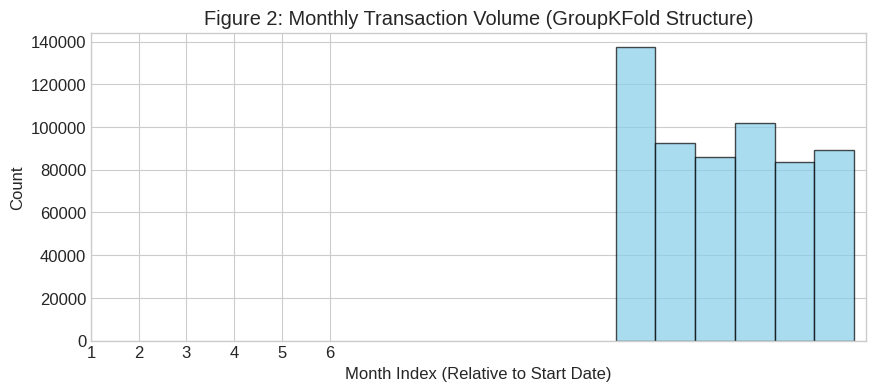

/tmp/ipykernel_17422/332767216.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.score.iloc[:20], y=data.index[:20], palette='magma')


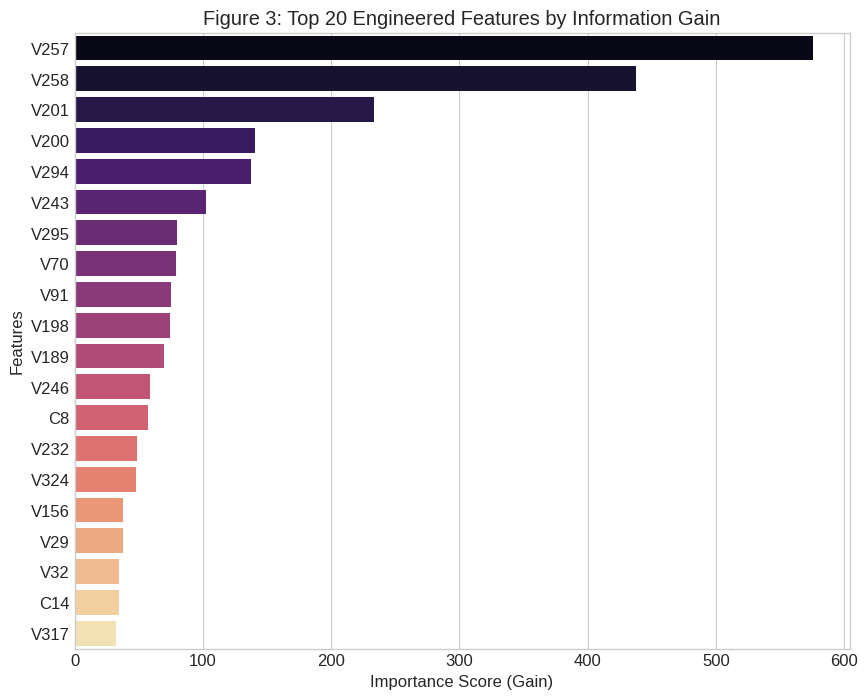

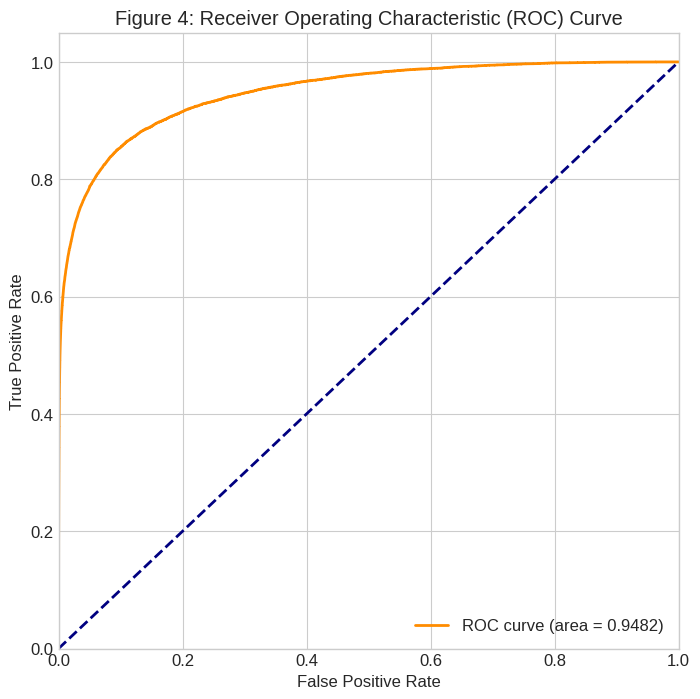

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Set professional plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16})

# --- Figure 1: Class Imbalance ---
plt.figure(figsize=(8, 6))
ax = sns.countplot(x=y_train, palette='viridis')
plt.title('Figure 1: Distribution of Fraudulent vs. Legitimate Transactions')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Number of Transactions')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_y()+p.get_height()+5000))
plt.show()

# --- Figure 2: Validation Strategy (Time-Based Groups) ---
plt.figure(figsize=(10, 4))
plt.hist(X_train['DT_M'], bins=6, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Figure 2: Monthly Transaction Volume (GroupKFold Structure)')
plt.xlabel('Month Index (Relative to Start Date)')
plt.ylabel('Count')
plt.xticks(range(1, 7))
plt.show()

# --- Figure 3: Feature Importance (Top 20) ---
feature_important = clf.get_booster().get_score(importance_type='gain')
keys = list(feature_important.keys())
values = list(feature_important.values())
data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by="score", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=data.score.iloc[:20], y=data.index[:20], palette='magma')
plt.title('Figure 3: Top 20 Engineered Features by Information Gain')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.show()

# --- Figure 4: ROC Curve (Validation Performance) ---
fpr, tpr, _ = roc_curve(y_train, oof)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Figure 4: Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

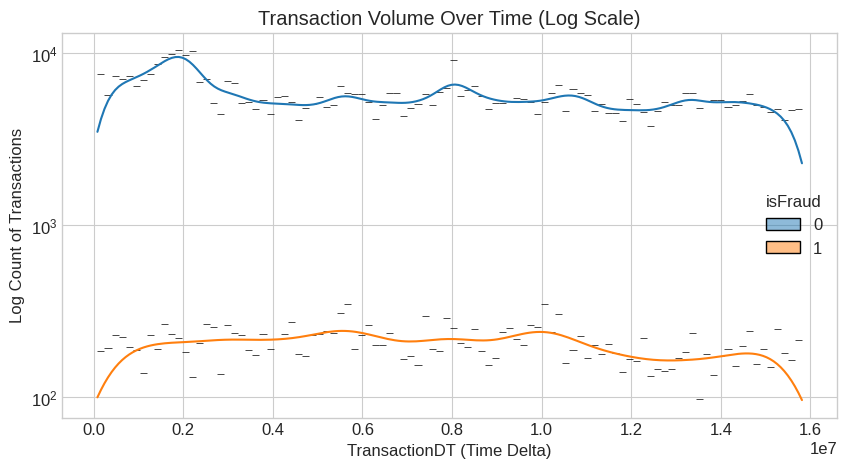

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a temporary dataframe just for plotting
plot_df = pd.DataFrame({
    'TransactionDT': X_train['TransactionDT'],
    'isFraud': y_train
})

# 2. Generate the plot
plt.figure(figsize=(10, 5))
sns.histplot(data=plot_df, x='TransactionDT', hue='isFraud', bins=100, kde=True, log_scale=(False, True))
plt.title("Transaction Volume Over Time (Log Scale)")
plt.xlabel("TransactionDT (Time Delta)")
plt.ylabel("Log Count of Transactions")

# 3. Save and show
plt.savefig('time_series_plot.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1240/2521621390.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='Blues_d')


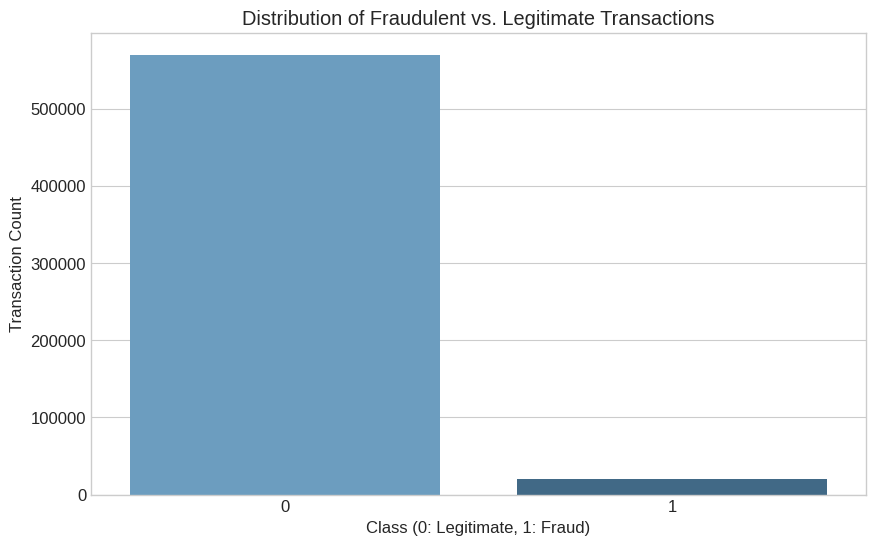

/tmp/ipykernel_1240/2521621390.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data_imp.score.iloc[:20], y=data_imp.index[:20], palette='viridis')


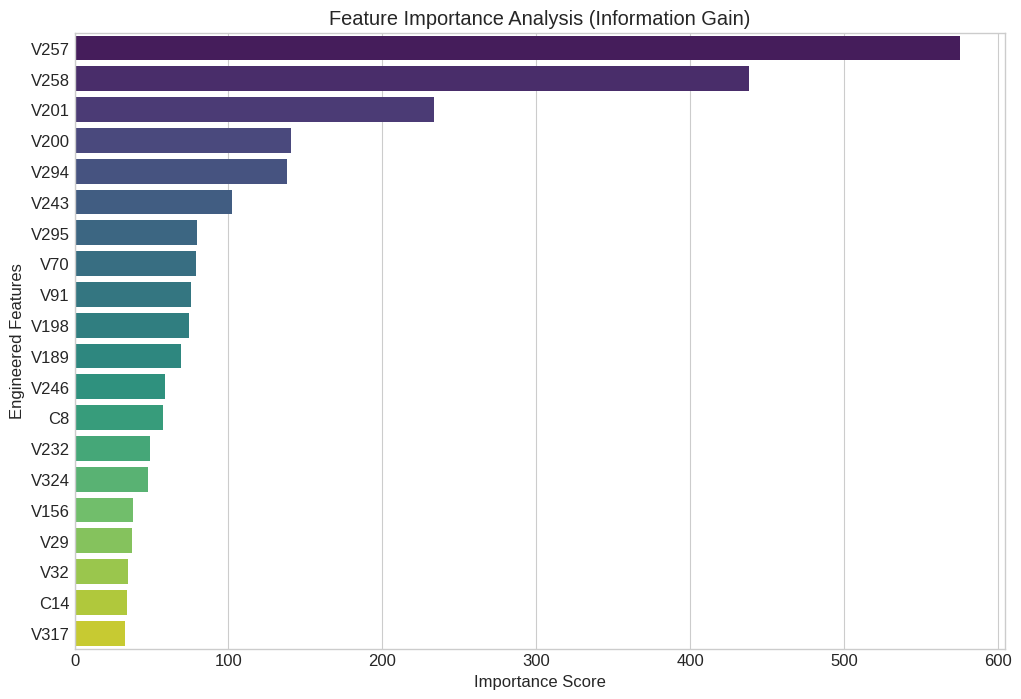

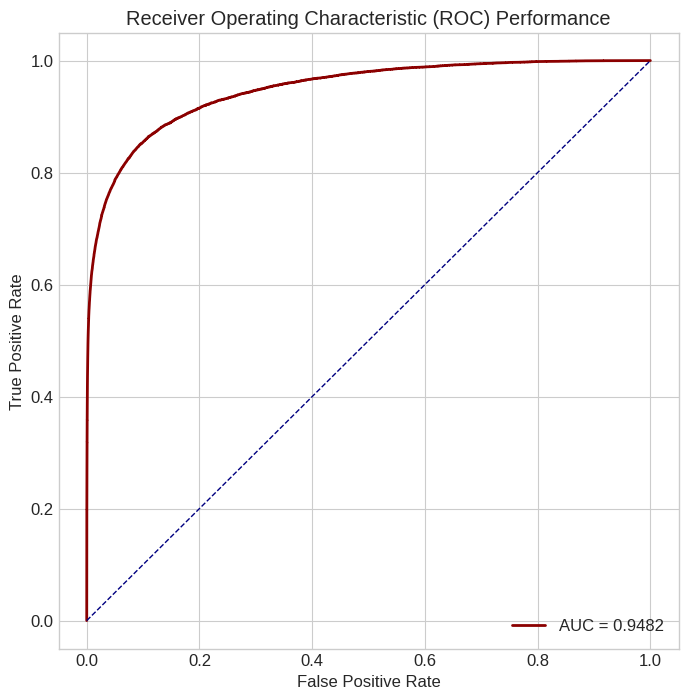

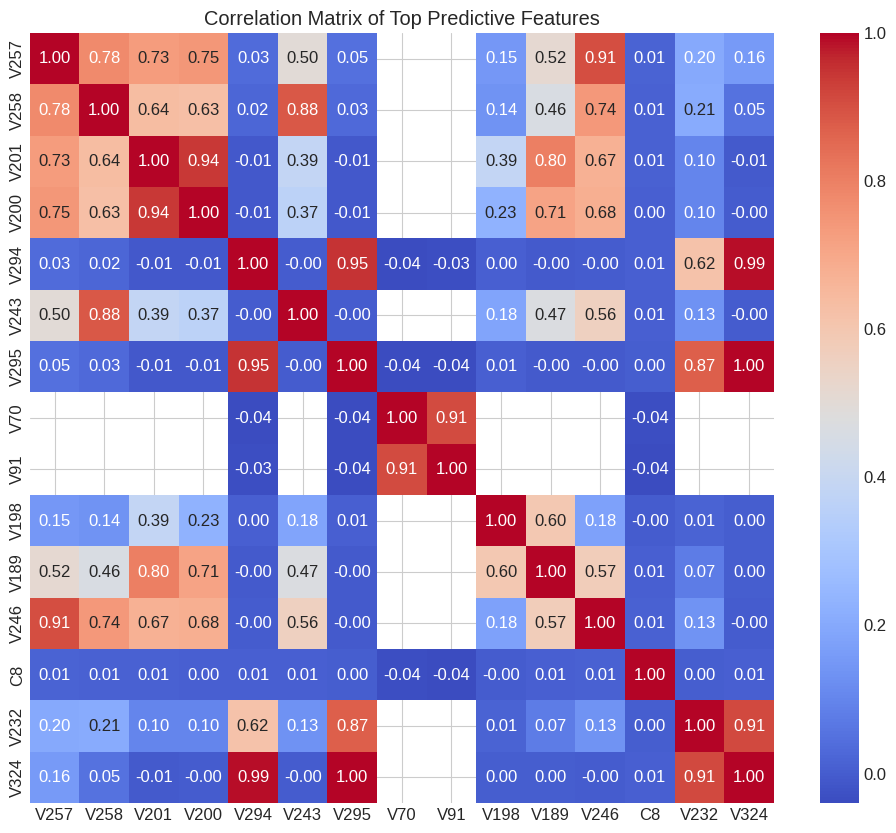

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np

# Set professional plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16})

# 1. Class Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train, palette='Blues_d')
plt.title('Distribution of Fraudulent vs. Legitimate Transactions')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Transaction Count')
plt.show()

# 2. Top 20 Feature Importance (Gain)
feature_important = clf.get_booster().get_score(importance_type='gain')
keys = list(feature_important.keys())
values = list(feature_important.values())
data_imp = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by="score", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=data_imp.score.iloc[:20], y=data_imp.index[:20], palette='viridis')
plt.title('Feature Importance Analysis (Information Gain)')
plt.xlabel('Importance Score')
plt.ylabel('Engineered Features')
plt.show()

# 3. Model Performance: ROC Curve
fpr, tpr, _ = roc_curve(y_train, oof)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Performance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# 4. Correlation Heatmap (Top Features)
top_features = data_imp.index[:15].tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(X_train[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Top Predictive Features')
plt.show()

In [ ]:
from IPython.display import display, HTML

# --- TABLE I: Transaction Description ---
trans_data = {
    'Feature': ['TransactionDT', 'TransactionAMT', 'ProductCD', 'Card1 - Card6', 'addr', 'dist', 'P and (R) emaindomain', 'C1-C14', 'D1-D15', 'M1-M9', 'Vxxx'],
    'Description': [
        'Timedelta from reference datetime (not a timestamp)',
        'Transaction payment amount in USD',
        'The code for each transaction',
        'Payment card info (type, category, bank, country)',
        'Address information',
        'Distance measurements',
        'Purchaser and recipient email domains',
        'Counting features (e.g., addresses per card)',
        'Timedeltas (e.g., days since last transaction)',
        'Identity matches (e.g., names on card and address)',
        'Vesta engineered rich features (ranking, counting, entities)'
    ]
}

# --- TABLE II: Identity Description ---
id_data = {
    'Feature': ['Device Type', 'Device Info', 'id_12 - id_38'],
    'Description': [
        'Type of machine customer uses',
        'Information of Machine',
        'Numerical features of identity'
    ]
}

df_trans = pd.DataFrame(trans_data)
df_id = pd.DataFrame(id_data)

print("TABLE I: Transaction Description")
display(df_trans.style.set_properties(**{'text-align': 'left'}).set_table_styles([dict(selector='th', props=[('text-align', 'center')])]))

print("\nTABLE II: Identity Description")
display(df_id.style.set_properties(**{'text-align': 'left'}).set_table_styles([dict(selector='th', props=[('text-align', 'center')])]))

TABLE I: Transaction Description


,Feature,Description
0,TransactionDT,Timedelta from reference datetime (not a timestamp)
1,TransactionAMT,Transaction payment amount in USD
2,ProductCD,The code for each transaction
3,Card1 - Card6,"Payment card info (type, category, bank, country)"
4,addr,Address information
5,dist,Distance measurements
6,P and (R) emaindomain,Purchaser and recipient email domains
7,C1-C14,"Counting features (e.g., addresses per card)"
8,D1-D15,"Timedeltas (e.g., days since last transaction)"
9,M1-M9,"Identity matches (e.g., names on card and address)"



TABLE II: Identity Description


,Feature,Description
0,Device Type,Type of machine customer uses
1,Device Info,Information of Machine
2,id_12 - id_38,Numerical features of identity


/tmp/ipykernel_17422/1494795497.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.score.head(20), y=data.index[:20], palette='magma')


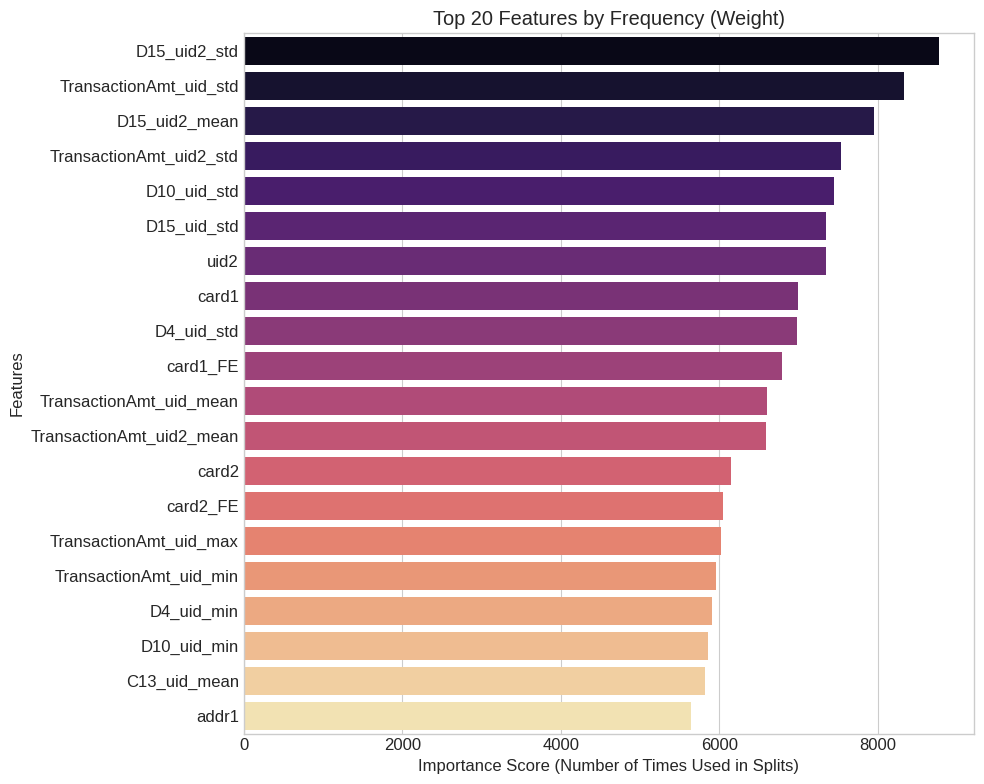

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plot style to match others
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16})

# Get Feature Importance (Weight type)
feature_important = clf.get_booster().get_score(importance_type='weight')
keys = list(feature_important.keys())
values = list(feature_important.values())
data = pd.DataFrame(data=values, index=keys, columns=['score']).sort_values(by='score', ascending=False)

# Create standardized Plot
plt.figure(figsize=(10, 8))
sns.barplot(x=data.score.head(20), y=data.index[:20], palette='magma')

plt.title('Top 20 Features by Frequency (Weight)')
plt.xlabel('Importance Score (Number of Times Used in Splits)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

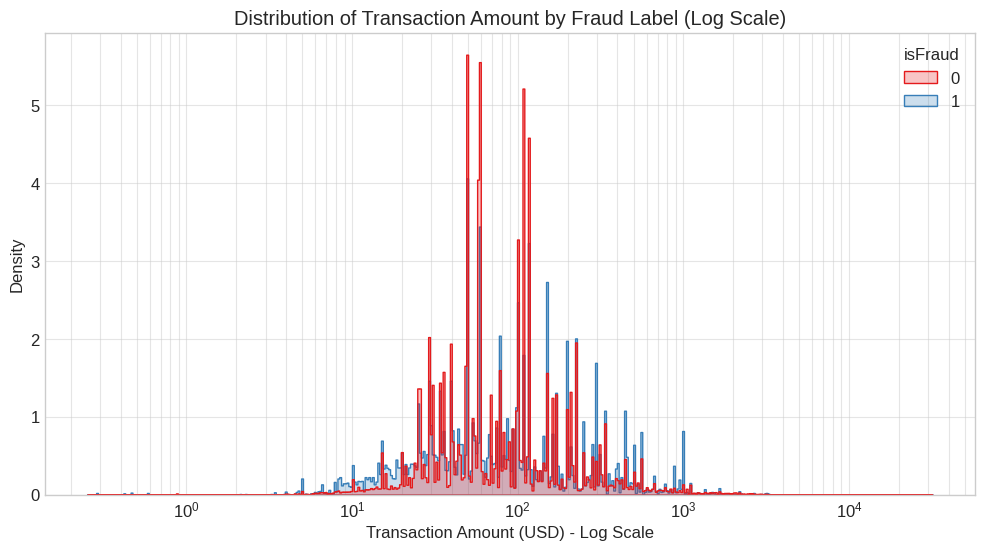

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# --- Sanity Check: TransactionAmt Distribution by Class ---
plt.figure(figsize=(12, 6))

# We use a log scale because TransactionAmt varies from $1 to $30,000
sns.histplot(data=X_train.assign(isFraud=y_train),
             x='TransactionAmt',
             hue='isFraud',
             element='step',
             stat='density',
             common_norm=False,
             log_scale=True,
             palette='Set1')

plt.title('Distribution of Transaction Amount by Fraud Label (Log Scale)')
plt.xlabel('Transaction Amount (USD) - Log Scale')
plt.ylabel('Density')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Dataset Sparsity: Out of 479 features, 392 columns contain missing values.
Top 20 Columns with Most Missing Values:


,Total Missing,% of Total Values
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_22,585371,99.124699
dist2,552913,93.628374
D7,551623,93.409930
id_18,545427,92.360721


/tmp/ipykernel_17422/1557853655.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_table['% of Total Values'].head(30), y=missing_table.index[:30], palette='Reds_r')


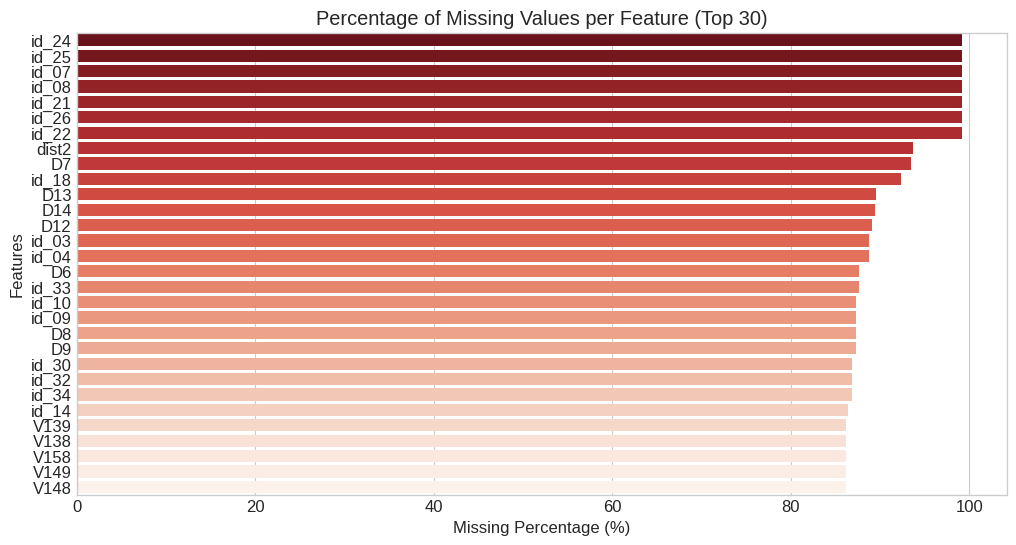

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate missing values
missing_values = X_train.isnull().sum()
missing_pct = 100 * X_train.isnull().sum() / len(X_train)

# Create summary dataframe
missing_table = pd.concat([missing_values, missing_pct], axis=1)
missing_table.columns = ['Total Missing', '% of Total Values']

# Filter to show only top columns with missing data
missing_table = missing_table[missing_table['Total Missing'] > 0].sort_values('% of Total Values', ascending=False)

print(f"Dataset Sparsity: Out of {X_train.shape[1]} features, {len(missing_table)} columns contain missing values.")
print("Top 20 Columns with Most Missing Values:")
display(missing_table.head(20).style.background_gradient(cmap='Reds'))

# Visualization for the paper
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_table['% of Total Values'].head(30), y=missing_table.index[:30], palette='Reds_r')
plt.title('Percentage of Missing Values per Feature (Top 30)')
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Features')
plt.show()

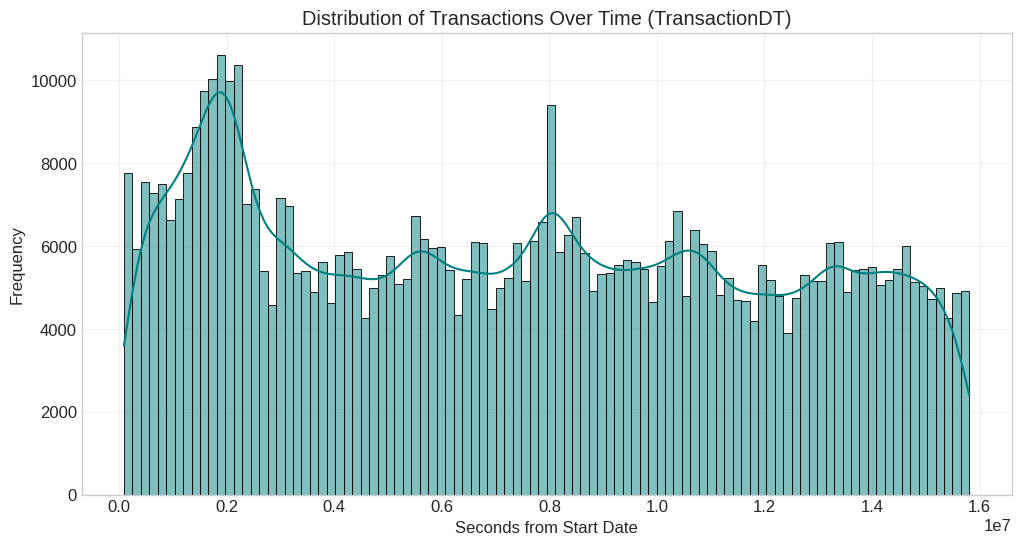

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.titlesize': 16})

plt.figure(figsize=(12, 6))
sns.histplot(X_train['TransactionDT'], bins=100, color='teal', kde=True)

plt.title('Distribution of Transactions Over Time (TransactionDT)')
plt.xlabel('Seconds from Start Date')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

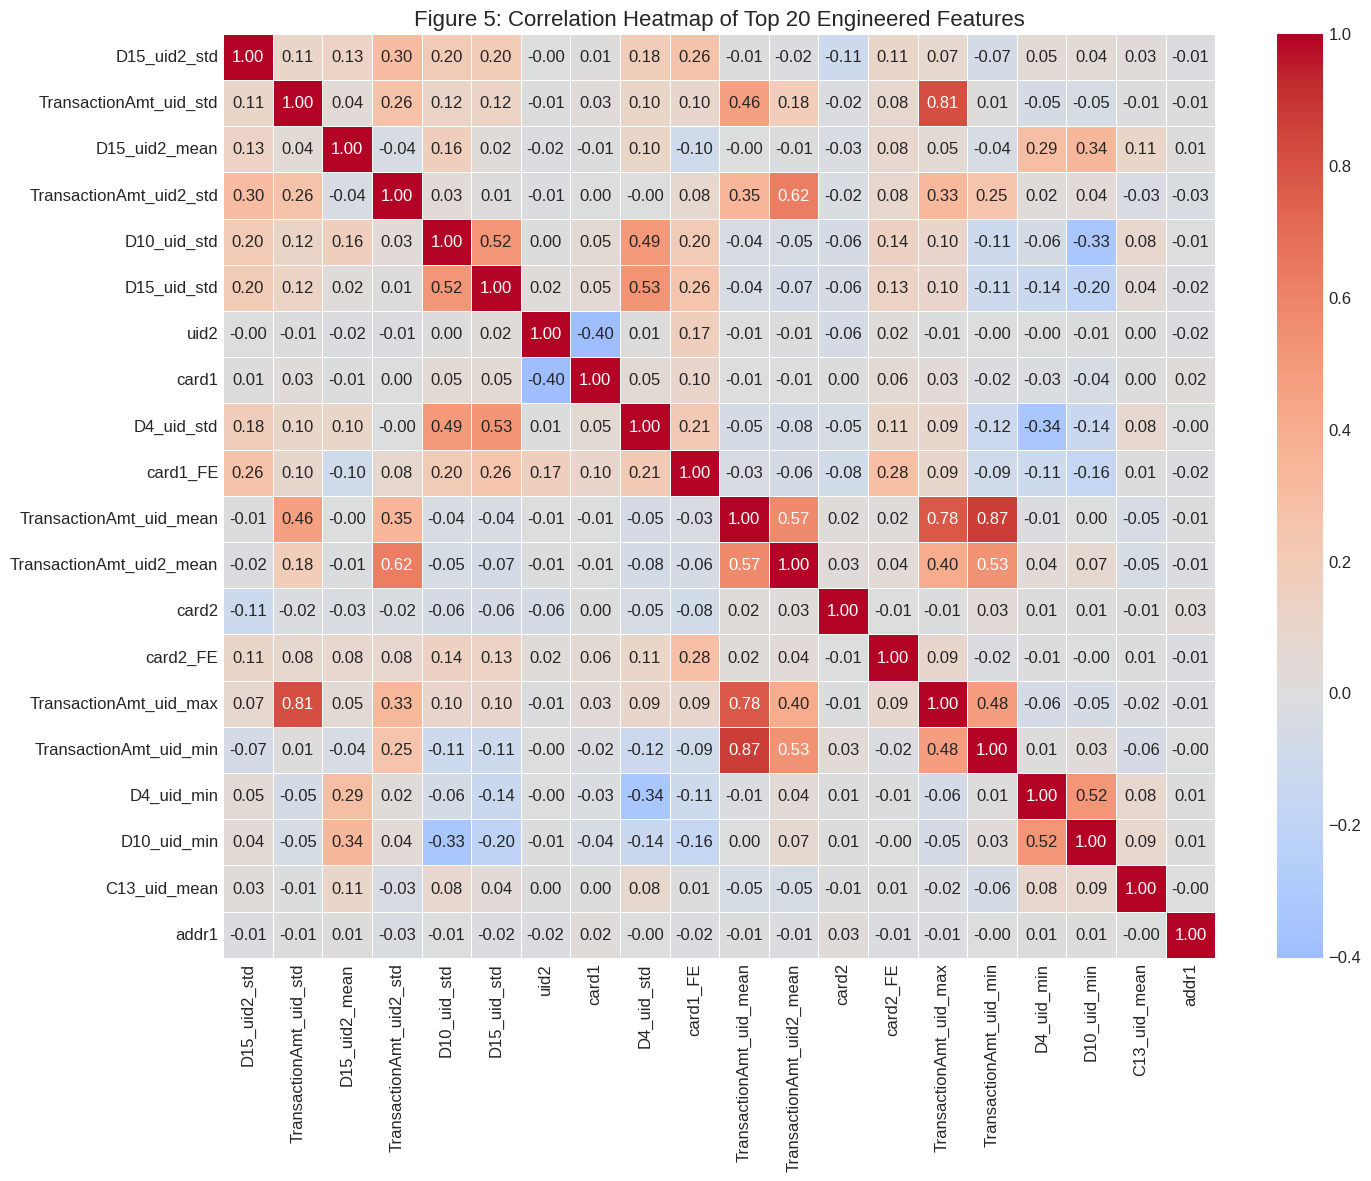

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify Top 20 features from the 'data' importance dataframe
top_20_features = data.index[:20].tolist()

# 2. Calculate Correlation Matrix
corr_matrix = X_train[top_20_features].corr()

# 3. Plot Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            center=0)

plt.title('Figure 5: Correlation Heatmap of Top 20 Engineered Features', fontsize=16)
plt.show()